<a href="https://colab.research.google.com/github/ShouriJalandar/ShouriJalandar.github.io/blob/main/Item_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Item Similarity**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/ml_tae/cleaned_products.csv"

df = pd.read_csv(data_path)

df.head()

,user_id,product_id,rating,product_name,brand_name,about_item,product_description,breadcrumbs,combined_text,weighted_rating
0,R199C1DG57O8P6,B07FMX9FSF,5.0,POLO RALPH LAUREN Men's Slim Fit Cotton Crew U...,POLO Store,"Length: 29.25in / 74cm, Chest: 41in / 104cm",POLO mens Polo Ralph Lauren Slim Fit Wicking C...,"Clothing, Shoes & Jewelry › Men › Clothing › U...",polo ralph lauren men's slim fit cotton crew u...,4.788114
1,R1UFTLDMUCDF0W,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
2,R12009XIWF7S1B,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
3,R30F5N17APS8XF,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
4,R3M1U8JP4SQ93K,B07FMZ31SR,4.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.288114


In [ ]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (2322, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2322 entries, 0 to 2321
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2322 non-null   object 
 1   product_id           2322 non-null   object 
 2   rating               2322 non-null   float64
 3   product_name         2322 non-null   object 
 4   brand_name           2322 non-null   object 
 5   about_item           2322 non-null   object 
 6   product_description  2322 non-null   object 
 7   breadcrumbs          2322 non-null   object 
 8   combined_text        2322 non-null   object 
 9   weighted_rating      2322 non-null   float64
dtypes: float64(2), object(8)
memory usage: 181.5+ KB


,rating,weighted_rating
count,2322.000000,2322.000000
mean,4.576227,4.576227
std,0.812178,0.406089
min,1.000000,2.788114
25%,4.000000,4.288114
50%,5.000000,4.788114
75%,5.000000,4.788114
max,5.000000,4.788114


In [ ]:
df_products = (
    df.sort_values("weighted_rating", ascending=False)
    .drop_duplicates(subset="product_id")
    .reset_index(drop=True)
)

print("Unique Products:", df_products.shape)

Unique Products: (254, 10)


In [ ]:
user_item_matrix = df.pivot_table(
    index="product_id",
    columns="user_id",
    values="rating"
).fillna(0)

user_item_matrix.head()

user_id,R100MAXRC1HW6S,R1032IGJQOTTRJ,R10406TM65ZLWM,R105XJ6QWC0GUL,R106QJVC8IVA5G,R107MUP04QKL2P,R107NGDUBMTC8D,R108EH9UYXAE8M,R10ATSAVN4XYOC,R10B3NGVBQSSKA,...,RZ1LVZ6QUGPMT,RZ35RXY548S4Q,RZ6V6TQKYFB9X,RZE32CG1PID6N,RZH9JS3NX02WG,RZJGDWLYWYNQ2,RZLF6ACV4N6Z7,RZOD5DTLVUBR2,RZZHKLN8KU2UC,RZZQS0KH57OD5
product_id,,,,,,,,,,,,,,,,,,,,,
B000J9YQOS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000SKI752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000U62IYK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000W93PX8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B0018OMIOI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
similarity_matrix = cosine_similarity(user_item_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

similarity_df.head()

product_id,B000J9YQOS,B000SKI752,B000U62IYK,B000W93PX8,B0018OMIOI,B0018ON68A,B001NSEC9I,B001NZCXNI,B002GHC19I,B005LCMU00,...,B0D1B42GVJ,B0D1H3W5K7,B0D36NX7KC,B0D5FXL1NC,B0D6NJP2H4,B0D6VDRSKS,B0D98NLXK8,B0DCP4FHYY,B0DGB7H1MB,B0DNF5CRSK
product_id,,,,,,,,,,,,,,,,,,,,,
B000J9YQOS,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000SKI752,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000U62IYK,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000W93PX8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B0018OMIOI,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def search_product(keyword):

    keyword = keyword.lower()

    matches = df_products[
        df_products["product_name"].str.lower().str.contains(keyword, na=False)
    ]

    if matches.empty:
        return None, None

    product_row = matches.iloc[0]

    return product_row["product_id"], product_row["breadcrumbs"]

In [ ]:
def recommend_items(keyword, top_n=5):

    product_id, category = search_product(keyword)

    if product_id is None:
        print("Product not found")
        return None

    if product_id not in similarity_df.index:
        print("Product not in similarity matrix")
        return None

    similarities = similarity_df[product_id].sort_values(ascending=False)

    similar_products = similarities.iloc[1:100].index

    recommendations = df_products[
        df_products["product_id"].isin(similar_products)
    ]

    # Category filtering
    recommendations = recommendations[
        recommendations["breadcrumbs"] == category
    ]

    recommendations = recommendations.drop_duplicates(subset=["product_name"])

    recommendations = recommendations.sort_values(
        by="weighted_rating",
        ascending=False
    )

    results = recommendations.head(top_n)[
        ["product_name","brand_name","breadcrumbs","weighted_rating"]
    ]

    return results

In [ ]:
product = input("Enter product name: ")

results = recommend_items(product, top_n=5)

results

Enter product name: jeans


,product_name,brand_name,breadcrumbs,weighted_rating
13,Wrangler Authentics Men's Regular Fit Comfort ...,Wrangler Store,"Clothing, Shoes & Jewelry › Men › Clothing › J...",4.788114
15,Wrangler Men's Regular Fit Comfort Flex Waist ...,Brand: Wrangler,"Clothing, Shoes & Jewelry › Men › Clothing › J...",4.788114
74,Levi Strauss Signature Gold Men's Relaxed Fit ...,Levi Strauss Signature Gold Store,"Clothing, Shoes & Jewelry › Men › Clothing › J...",4.788114
80,Levi's Men's 559 Relaxed Straight Jeans (Also ...,Levi's Store,"Clothing, Shoes & Jewelry › Men › Clothing › J...",4.788114
82,Amazon Essentials Slim Fit Jeans For Men,Amazon Essentials Store,"Clothing, Shoes & Jewelry › Men › Clothing › J...",4.788114


In [ ]:
df["relevant"] = (df["rating"] >= 4).astype(int)

y_true = df["relevant"]

y_pred = (df["weighted_rating"] >= 4).astype(int)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

roc_auc = roc_auc_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


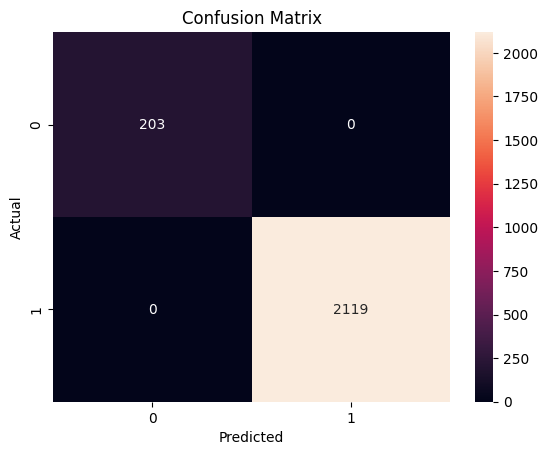

In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# PRECISION@K AND RECALL@K
def precision_at_k(results, k=5):

    relevant = results["weighted_rating"] >= 4

    return relevant.sum() / k


def recall_at_k(results, total_relevant):

    relevant = results["weighted_rating"] >= 4

    return relevant.sum() / total_relevant


p_at_k = precision_at_k(results, 5)

total_relevant = df[df["rating"] >= 4].shape[0]

r_at_k = recall_at_k(results, total_relevant)

print("Precision@5:", p_at_k)

print("Recall@5:", r_at_k)

Precision@5: 1.0
Recall@5: 0.0023596035865974517


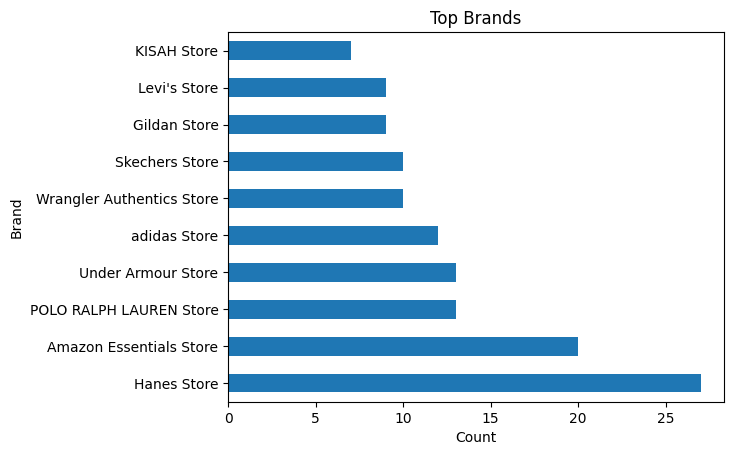

In [ ]:
top_brands = df_products['brand_name'].value_counts().head(10)

top_brands.plot(kind='barh')

plt.title("Top Brands")

plt.xlabel("Count")

plt.ylabel("Brand")

plt.show()

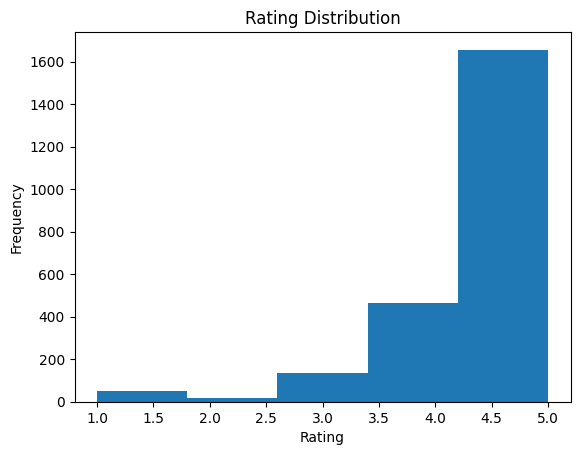

In [ ]:
plt.hist(df["rating"], bins=5)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()